# Water Quality ML Fecal Coliform Prediction
# Group 5
> **Goal:** Train 5 regression models then compare with 5-Fold CV next predict Fecal Coliform then  
> classify water as **Safe / Not Safe** (threshold = 50 MPN/100 mL).


## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, classification_report, confusion_matrix)
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor)
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)
print("Libraries loaded.")
from sklearn.preprocessing import QuantileTransformer

Libraries loaded.


## Load Cleaned Data

In [2]:
# Update path to your cleaned CSV
df = pd.read_csv(r"c:\Users\Dell\Downloads\water_quality_cleaneddata1.csv")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("Columns:", df.columns.tolist())
df.head()

Loaded: 2,617 rows × 23 columns
Columns: ['Water_Body_Type', 'State_Name', 'Year', 'Temperature', 'DO', 'pH', 'Conductivity', 'BOD', 'Nitrate_Nitrite', 'Fecal_Coliform', 'Total_Coliform', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log', 'Total_Coliform_log', 'Fecal_Coliform_log', 'DO_sqrt', 'BOD_Temp', 'BOD_Conductivity', 'Nitrate_Temp', 'BOD_Temp_log', 'BOD_Conductivity_log', 'Is_Monsoon']


,Water_Body_Type,State_Name,Year,Temperature,DO,pH,Conductivity,BOD,Nitrate_Nitrite,Fecal_Coliform,...,Nitrate_Nitrite_log,Total_Coliform_log,Fecal_Coliform_log,DO_sqrt,BOD_Temp,BOD_Conductivity,Nitrate_Temp,BOD_Temp_log,BOD_Conductivity_log,Is_Monsoon
0,LAKE,ANDHRA \nPRADESH,2017,26.0000,6.3500,7.6500,815.5000,1.8000,2.2600,20.0000,...,1.1817,7.2269,3.0445,2.5199,46.8000,1467.9000,58.7600,3.8670,7.2923,1
1,LAKE,ASSAM,2017,23.5000,4.7000,6.6000,89.0000,8.6000,0.9000,1150.0000,...,0.6419,8.1259,7.0484,2.1679,202.1000,765.4000,21.1500,5.3137,6.6417,1
2,LAKE,ASSAM,2017,29.0000,5.5500,7.2000,103.5000,1.8500,0.7500,750.0000,...,0.5596,7.9377,6.6214,2.3558,53.6500,191.4750,21.7500,4.0009,5.2600,1
3,POND,ASSAM,2017,28.0000,2.6500,7.6000,617.5000,9.6000,3.2500,2300.0000,...,1.4469,9.2934,7.7411,1.6279,268.8000,5928.0000,91.0000,5.5977,8.6876,1
4,POND,ASSAM,2017,27.5000,5.1500,6.7000,130.5000,10.1500,1.2000,1200.0000,...,0.7885,9.5943,7.0909,2.2694,279.1250,1324.5750,33.0000,5.6352,7.1896,1


## Feature Selection & Encoding

**Column contract (must match EDA output):**

| Feature | Column used in model |
|---|---|
| Temperature | `Temperature` |
| Dissolved Oxygen | `DO_sqrt` |
| pH | `pH` |
| Conductivity | `Conductivity_log` |
| BOD | `BOD_log` |
| Nitrate/Nitrite | `Nitrate_Nitrite_log` |
| Water body type | One-hot from `Water_Body_Type` |
| State | Frequency-encoded from `State_Name` |

**No winsorizing done once in EDA.**

In [3]:
# Drop leakage and non-feature columns
DROP_COLS = ['Total_Coliform', 'Total_Coliform_log',
             'Fecal_Coliform_log',           # log of target — not a feature
             'DO',                            # raw version; using DO_sqrt
             'Conductivity', 'BOD', 'Nitrate_Nitrite',  # raw; using _log versions
             'State_WaterType']               # composite label, not a feature
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True, errors='ignore')
print("After dropping leakage/redundant columns:")
print(df.columns.tolist())

After dropping leakage/redundant columns:
['Water_Body_Type', 'State_Name', 'Year', 'Temperature', 'pH', 'Fecal_Coliform', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log', 'DO_sqrt', 'BOD_Temp', 'BOD_Conductivity', 'Nitrate_Temp', 'BOD_Temp_log', 'BOD_Conductivity_log', 'Is_Monsoon']


In [4]:
# Validate that all required feature columns exist
REQUIRED_FEATURES = ['Temperature', 'DO_sqrt', 'pH',
                     'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log']

missing = [c for c in REQUIRED_FEATURES if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns — check EDA notebook output: {missing}")
else:
    print("All required feature columns present.")
    print(REQUIRED_FEATURES)

All required feature columns present.
['Temperature', 'DO_sqrt', 'pH', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log']


In [5]:
# One-hot encode Water_Body_Type
if 'Water_Body_Type' in df.columns:
    df = pd.get_dummies(df, columns=['Water_Body_Type'], drop_first=True)
    wb_dummies = [c for c in df.columns if c.startswith('Water_Body_Type_')]
    print("Water body dummies created:", wb_dummies)
else:
    wb_dummies = []
    print("Water_Body_Type column not found — skipping one-hot encoding.")

# Frequency encode State_Name
if 'State_Name' in df.columns:
    freq = df['State_Name'].value_counts(normalize=True)
    df['State_freq'] = df['State_Name'].map(freq)
    df.drop(columns=['State_Name'], inplace=True)
    extra_cols = ['State_freq'] + wb_dummies
    print("State_Name frequency-encoded.")
else:
    extra_cols = wb_dummies

# Final feature list
FEATURE_COLS = REQUIRED_FEATURES + extra_cols
print("\nFinal feature list:", FEATURE_COLS)
# ── Add new engineered features if present (from EDA notebook) ──
NEW_FEATURES = ['BOD_Temp_log', 'BOD_Conductivity_log', 'Nitrate_Temp', 'Is_Monsoon']
for f in NEW_FEATURES:
    if f in df.columns:
        FEATURE_COLS.append(f)

print("\nFinal feature list (with new features if available):", FEATURE_COLS)


Water body dummies created: ['Water_Body_Type_POND', 'Water_Body_Type_TANK', 'Water_Body_Type_WETLAND', 'Water_Body_Type_Wetland']
State_Name frequency-encoded.

Final feature list: ['Temperature', 'DO_sqrt', 'pH', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log', 'State_freq', 'Water_Body_Type_POND', 'Water_Body_Type_TANK', 'Water_Body_Type_WETLAND', 'Water_Body_Type_Wetland']

Final feature list (with new features if available): ['Temperature', 'DO_sqrt', 'pH', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log', 'State_freq', 'Water_Body_Type_POND', 'Water_Body_Type_TANK', 'Water_Body_Type_WETLAND', 'Water_Body_Type_Wetland', 'BOD_Temp_log', 'BOD_Conductivity_log', 'Nitrate_Temp', 'Is_Monsoon']


## Define X and y

In [6]:
TARGET = 'Fecal_Coliform'

X     = df[FEATURE_COLS].copy()
y_raw = df[TARGET].copy()      # original scale — kept for reporting

# QuantileTransformer maps the skewed target to a normal distribution,
# which works better than plain log1p for heavily skewed targets.
qt = QuantileTransformer(output_distribution='normal', random_state=42)
y  = qt.fit_transform(y_raw.values.reshape(-1, 1)).flatten()

print(f"Features : {len(FEATURE_COLS)}")
print(f"X shape  : {X.shape}")
print(f"y (raw)  : min={y_raw.min():.1f}  max={y_raw.max():.1f}  median={y_raw.median():.1f}")
print(f"y (qt)   : min={y.min():.3f}  max={y.max():.3f}  median={np.median(y):.3f}")
print("Target transformed with QuantileTransformer (output_distribution='normal').")


Features : 15
X shape  : (2617, 15)
y (raw)  : min=1.0  max=1779500.0  median=250.0
y (qt)   : min=-5.199  max=5.199  median=0.001
Target transformed with QuantileTransformer (output_distribution='normal').


## Train/Test Split + K-Fold Setup

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Keep raw test labels for metric reporting
y_test_raw  = y_raw.loc[X_test.index]
y_train_raw = y_raw.loc[X_train.index]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train : {X_train.shape[0]:,} rows")
print(f"Test  : {X_test.shape[0]:,} rows")
print("K-Fold : 5 splits, on training set only.")


Train : 2,093 rows
Test  : 524 rows
K-Fold : 5 splits, on training set only.


## Define 4 Models

In [8]:
MODELS = {
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=500, max_depth=None, min_samples_split=2,
        random_state=42, n_jobs=-1),

    "Random Forest": RandomForestRegressor(
        n_estimators=400, random_state=42, n_jobs=-1),

    "XGBoost": XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=8,
        random_state=42, verbosity=0),

    "CatBoost": CatBoostRegressor(
        iterations=400, learning_rate=0.05, depth=8,
        random_seed=42, verbose=0),
}
for name in MODELS: print(f" • {name}")


 • Extra Trees
 • Random Forest
 • XGBoost
 • CatBoost


## 5-Fold Cross-Validation + Hold-out Test

In [9]:
def fit_and_evaluate(model, X_tr, y_tr, X_te, y_te_raw):
    """Train on log-scale, predict, convert to original scale, return metrics."""
    model.fit(X_tr, y_tr)
    pred_log = model.predict(X_te)
    pred_raw = qt.inverse_transform(pred_log.reshape(-1, 1)).flatten().clip(0)
    mae  = mean_absolute_error(y_te_raw, pred_raw)
    rmse = np.sqrt(mean_squared_error(y_te_raw, pred_raw))
    r2   = r2_score(y_te_raw, pred_raw)
    return pred_raw, mae, rmse, r2


cv_summary   = {}
test_results = []
fitted       = {}

print("Running 5-Fold CV...\n")
print(f"{'Model':<22} {'CV RMSE mean':>14} {'CV RMSE std':>12} {'CV R² mean':>12}")

for name, model in MODELS.items():
    cv_rmse = cross_val_score(model, X_train, y_train, cv=kf,
                               scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_r2   = cross_val_score(model, X_train, y_train, cv=kf,
                               scoring='r2', n_jobs=-1)
    cv_summary[name] = {'CV RMSE mean': (-cv_rmse).mean(),
                        'CV RMSE std':  (-cv_rmse).std(),
                        'CV R² mean':   cv_r2.mean()}

    preds, mae, rmse, r2 = fit_and_evaluate(
        model, X_train, y_train, X_test, y_test_raw)
    fitted[name] = (model, preds)
    test_results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2})

    print(f"{name:<22} {(-cv_rmse).mean():>14.4f} {(-cv_rmse).std():>12.4f} {cv_r2.mean():>12.4f}")

print("\n Cross-validation complete.")

Running 5-Fold CV...

Model                    CV RMSE mean  CV RMSE std   CV R² mean
Extra Trees                    0.4872       0.0168       0.7708
Random Forest                  0.5042       0.0254       0.7548
XGBoost                        0.5170       0.0312       0.7419
CatBoost                       0.4987       0.0129       0.7598

 Cross-validation complete.


## Results Table

In [11]:
results_df = pd.DataFrame(test_results).sort_values('R²', ascending=False).reset_index(drop=True)

print("FINAL RESULTS, Hold-out Test Set (Original Scale)")
print(results_df.to_string(index=False))

# Best model = highest R² (primary metric for regression quality)
best_row  = results_df.iloc[0]
BEST_NAME = best_row['Model']
print(f"\n BEST MODEL : {BEST_NAME}  (selected by R²)")
print(f"   MAE  = {best_row['MAE']:,.2f}")
print(f"   RMSE = {best_row['RMSE']:,.2f}")
print(f"   R²   = {best_row['R²']:.4f}")


FINAL RESULTS, Hold-out Test Set (Original Scale)
        Model        MAE        RMSE     R²
  Extra Trees 21357.5190  96588.8984 0.3050
     CatBoost 21255.1757 101655.2223 0.2302
Random Forest 22631.9210 103180.8821 0.2069
      XGBoost 26172.7745 113147.2020 0.0463

 BEST MODEL : Extra Trees  (selected by R²)
   MAE  = 21,357.52
   RMSE = 96,588.90
   R²   = 0.3050


## Model Comparison Chart

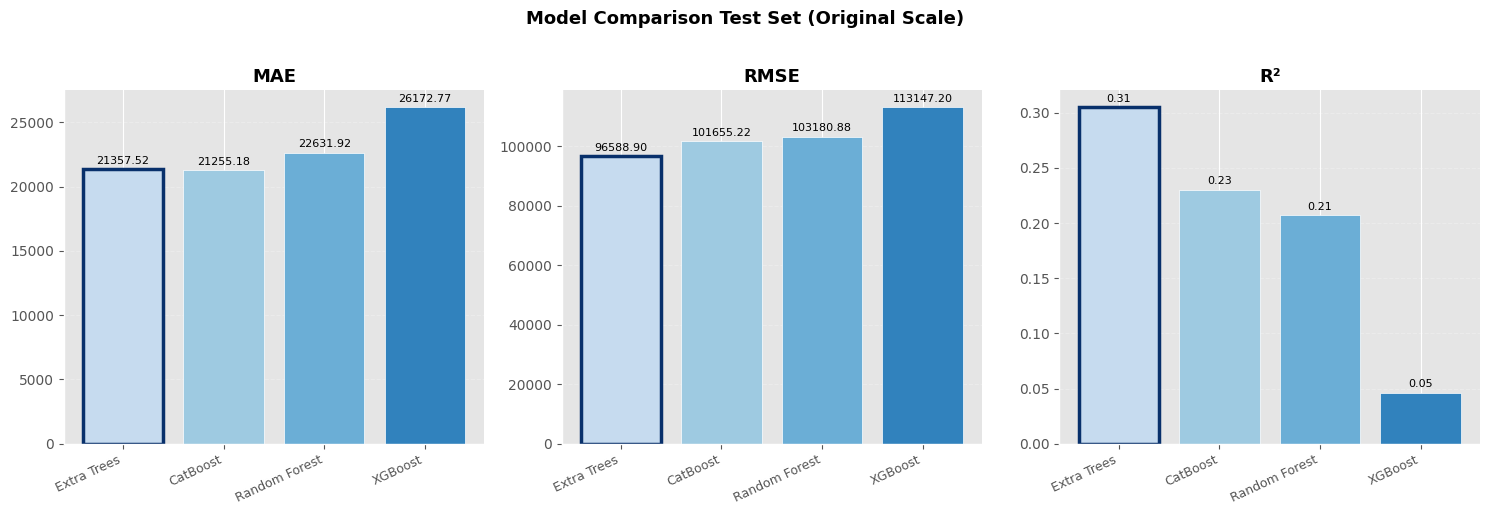

Saved model_comparison.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Classic blue gradient palette (professional / paper style)
palette = [
    "#c6dbef",
    "#9ecae1",
    "#6baed6",
    "#3182bd",
    "#08519c"
]

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    vals = results_df[metric]
    names = results_df['Model']

    bars = ax.bar(names, vals, color=palette, edgecolor='white')

    # best model highlight
    best_idx = results_df['R²'].idxmax()  # always highlight the R²-best model
    bars[best_idx].set_edgecolor('#08306b')
    bars[best_idx].set_linewidth(2.5)

    # value labels
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01 * vals.max(),
            f'{val:.2f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9)

    ax.grid(axis='y', linestyle='--', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Model Comparison Test Set (Original Scale)',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()

plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved model_comparison.png")

## Train Best Model on Full Data & Save

In [13]:
print(f"Training {BEST_NAME} on full dataset...")
best_model = MODELS[BEST_NAME]
best_model.fit(X, y)

joblib.dump(best_model,  'best_model.pkl')
joblib.dump(FEATURE_COLS,'feature_cols.pkl')

print(f" best_model.pkl saved")
print(f" feature_cols.pkl saved")
print(f"  Features: {FEATURE_COLS}")

Training Extra Trees on full dataset...
 best_model.pkl saved
 feature_cols.pkl saved
  Features: ['Temperature', 'DO_sqrt', 'pH', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log', 'State_freq', 'Water_Body_Type_POND', 'Water_Body_Type_TANK', 'Water_Body_Type_WETLAND', 'Water_Body_Type_Wetland', 'BOD_Temp_log', 'BOD_Conductivity_log', 'Nitrate_Temp', 'Is_Monsoon']


## Predictions + Safe / Not Safe Classification

| Threshold | Label |
|---|---|
| Fecal Coliform ≤ 50 MPN/100 mL |  Safe |
| Fecal Coliform > 50 MPN/100 mL |  Not Safe |

In [13]:
SAFE_THRESHOLD = 50   # MPN / 100 mL

best_fitted = fitted[BEST_NAME][0]
pred_log    = best_fitted.predict(X_test)
pred_raw    = qt.inverse_transform(pred_log.reshape(-1, 1)).flatten().clip(0)

pred_label   = pd.Series(pred_raw).apply(lambda x: 'Safe' if x <= SAFE_THRESHOLD else 'Not Safe')
actual_label = y_test_raw.apply(lambda x: 'Safe' if x <= SAFE_THRESHOLD else 'Not Safe')

sample = pd.DataFrame({
    'Actual FC (MPN)'     : y_test_raw.values[:10].round(2),
    'Predicted FC (MPN)'  : pred_raw[:10].round(2),
    'Actual Label'        : actual_label.values[:10],
    'Predicted Label'     : pred_label.values[:10],
})
print("Sample predictions (first 10):")
print(sample.to_string(index=False))

Sample predictions (first 10):
 Actual FC (MPN)  Predicted FC (MPN) Actual Label Predicted Label
         17.5000             30.3100         Safe            Safe
         57.0000            181.0000     Not Safe        Not Safe
        220.0000          13765.9400     Not Safe        Not Safe
        605.0000            370.0000     Not Safe        Not Safe
         27.5000             17.5000         Safe            Safe
      14350.0000            860.2900     Not Safe        Not Safe
      20042.0000         107714.3600     Not Safe        Not Safe
      23850.0000          23643.2700     Not Safe        Not Safe
       1650.0000            707.3500     Not Safe        Not Safe
         13.5000             36.6000         Safe            Safe


## Classification Report + Confusion Matrix

CLASSIFICATION REPORT (Safe vs Not Safe)
              precision    recall  f1-score   support

    Not Safe       0.92      0.91      0.92       352
        Safe       0.83      0.84      0.84       172

    accuracy                           0.89       524
   macro avg       0.88      0.88      0.88       524
weighted avg       0.89      0.89      0.89       524



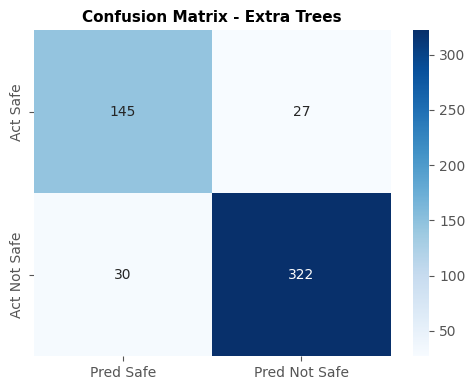

In [17]:
print("CLASSIFICATION REPORT (Safe vs Not Safe)")
print(classification_report(actual_label, pred_label, target_names=['Not Safe','Safe']))

cm = confusion_matrix(actual_label, pred_label, labels=['Safe','Not Safe'])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Safe','Pred Not Safe'],
            yticklabels=['Act Safe', 'Act Not Safe'], ax=ax)
ax.set_title(f'Confusion Matrix - {BEST_NAME}', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Importance

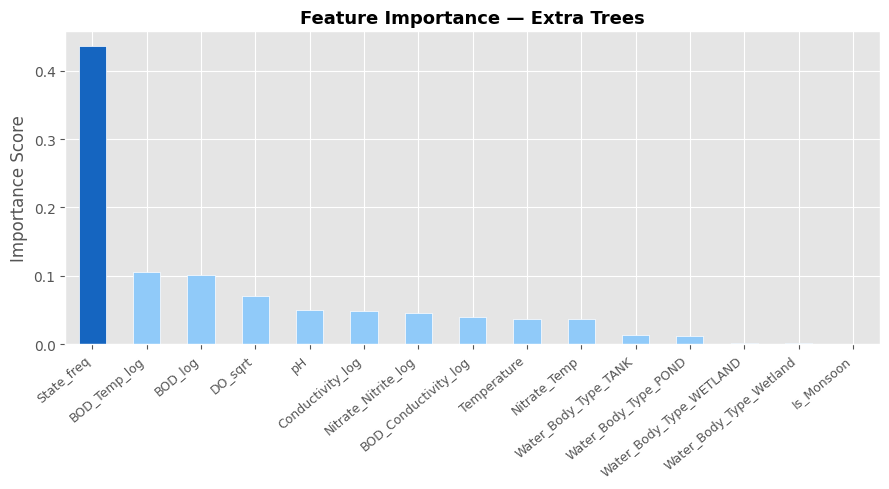

Saved feature_importance.png

Top features:
State_freq     0.4356
BOD_Temp_log   0.1056
BOD_log        0.1016
DO_sqrt        0.0708
pH             0.0494


In [15]:
if hasattr(best_fitted, 'feature_importances_'):
    importances = pd.Series(best_fitted.feature_importances_, index=FEATURE_COLS)
    importances = importances.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['#1565C0' if i == 0 else '#90CAF9' for i in range(len(importances))]
    importances.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'Feature Importance — {BEST_NAME}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Importance Score')
    ax.set_xticklabels(importances.index, rotation=40, ha='right', fontsize=9)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show();  print("Saved feature_importance.png")
    print("\nTop features:")
    print(importances.head().to_string())
else:
    print(f"{BEST_NAME} does not expose feature_importances_")

## Actual vs Predicted Plot

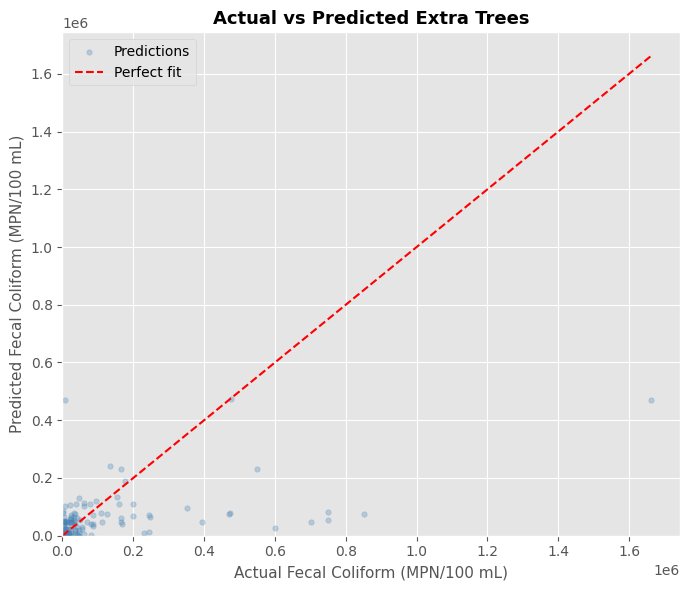

Saved actual_vs_predicted.png


In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_raw, pred_raw, alpha=0.3, s=15, color='steelblue', label='Predictions')
max_v = max(float(y_test_raw.max()), float(pred_raw.max()))
ax.plot([0, max_v], [0, max_v], 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual Fecal Coliform (MPN/100 mL)', fontsize=11)
ax.set_ylabel('Predicted Fecal Coliform (MPN/100 mL)', fontsize=11)
ax.set_title(f'Actual vs Predicted {BEST_NAME}', fontsize=13, fontweight='bold')
ax.legend();  ax.set_xlim(left=0);  ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show();  print("Saved actual_vs_predicted.png")

## Hyperparameter Tuning Extra Trees (RandomizedSearchCV)

> Runs 50 random combinations × 5-fold CV on the **training set only**.  
> Best params are then evaluated on the **hold-out test set**.


In [19]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Search space 
param_dist = {
    'n_estimators'    : randint(300, 800),
    'max_depth'       : [None, 10, 20, 30, 40],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 10),
    'max_features'    : ['sqrt', 'log2', 0.5, 0.7, None],
}

base_et = ExtraTreesRegressor(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    estimator   = base_et,
    param_distributions = param_dist,
    n_iter      = 50,
    cv          = KFold(n_splits=5, shuffle=True, random_state=42),
    scoring     = 'r2',
    random_state= 42,
    n_jobs      = -1,
    verbose     = 1,
    refit       = True
)

print("Running RandomizedSearchCV (50 iterations × 5-fold)...")
search.fit(X_train, y_train)

print("\n BEST PARAMETERS")
for k, v in search.best_params_.items():
    print(f"  {k:<22}: {v}")
print(f"\nBest CV R² (training set): {search.best_score_:.4f}")


Running RandomizedSearchCV (50 iterations × 5-fold)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

 BEST PARAMETERS
  max_depth             : None
  max_features          : 0.7
  min_samples_leaf      : 1
  min_samples_split     : 3
  n_estimators          : 684

Best CV R² (training set): 0.7671


In [22]:
# Evaluate tuned model on hold-out test set 
tuned_et = search.best_estimator_

pred_trans_tuned = tuned_et.predict(X_test)
pred_raw_tuned   = qt.inverse_transform(
    pred_trans_tuned.reshape(-1, 1)).flatten().clip(0)

mae_t  = mean_absolute_error(y_test_raw, pred_raw_tuned)
rmse_t = np.sqrt(mean_squared_error(y_test_raw, pred_raw_tuned))
r2_t   = r2_score(y_test_raw, pred_raw_tuned)

print(" TUNED EXTRA TREES, Hold-out Test Set ")
print(f"  MAE  : {mae_t:,.2f}")
print(f"  RMSE : {rmse_t:,.2f}")
print(f"  R²   : {r2_t:.4f}")

# Compare with baseline Extra Trees
baseline = results_df[results_df['Model'] == 'Extra Trees'].iloc[0]
print("\n IMPROVEMENT")
print(f"  R²   : {baseline['R²']:.4f} to  {r2_t:.4f}  (Δ {r2_t - baseline['R²']:+.4f})")
print(f"  MAE  : {baseline['MAE']:,.1f}  to  {mae_t:,.1f}  (Δ {mae_t - baseline['MAE']:+,.1f})")
print(f"  RMSE : {baseline['RMSE']:,.1f}  to  {rmse_t:,.1f}  (Δ {rmse_t - baseline['RMSE']:+,.1f})")


 TUNED EXTRA TREES, Hold-out Test Set 
  MAE  : 20,756.08
  RMSE : 95,667.82
  R²   : 0.3182

 IMPROVEMENT
  R²   : 0.3050 to  0.3182  (Δ +0.0132)
  MAE  : 21,357.5  to  20,756.1  (Δ -601.4)
  RMSE : 96,588.9  to  95,667.8  (Δ -921.1)


In [23]:
# Save tuned model
joblib.dump(tuned_et,    'best_model_tuned.pkl')
joblib.dump(FEATURE_COLS,'feature_cols.pkl')
print("Saved: best_model_tuned.pkl")
print(f"Features: {FEATURE_COLS}")


Saved: best_model_tuned.pkl
Features: ['Temperature', 'DO_sqrt', 'pH', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log', 'State_freq', 'Water_Body_Type_POND', 'Water_Body_Type_TANK', 'Water_Body_Type_WETLAND', 'Water_Body_Type_Wetland', 'BOD_Temp_log', 'BOD_Conductivity_log', 'Nitrate_Temp', 'Is_Monsoon']


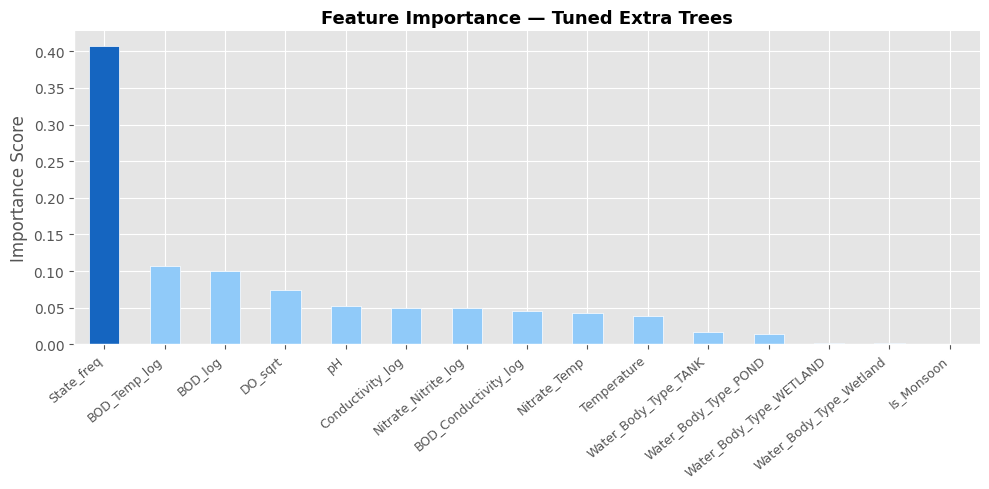

Top 5 features:
State_freq     0.4069
BOD_Temp_log   0.1064
BOD_log        0.0994
DO_sqrt        0.0742
pH             0.0528


In [ ]:
# Feature importance(tuned model)
importances = pd.Series(tuned_et.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1565C0' if i == 0 else '#90CAF9' for i in range(len(importances))]
importances.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance Tuned Extra Trees', fontsize=13, fontweight='bold')
ax.set_ylabel('Importance Score')
ax.set_xticklabels(importances.index, rotation=40, ha='right', fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('feature_importance_tuned.png', dpi=150, bbox_inches='tight')
plt.show()
print("Top 5 features:")
print(importances.head().to_string())


## Pipeline Summary

| Step | Status |
|---|---|
| Load cleaned data (no re-cleaning) | Done |
| Validate required columns exist | Done |
| Encode Water_Body_Type + State_Name | Done |
| Train on log1p(Fecal_Coliform) | Done |
| 5-Fold CV on 4 models | Done |
| Report metrics in original scale | Done |
| Best model saved (.pkl) | Done |
| Safe / Not Safe (threshold = 50) | Done |
| Classification report + confusion matrix | Done |
| Feature importance chart | Done |

In [25]:
# 1. Check target distribution
print("Target (Fecal_Coliform) Statistics:")
print(y_raw.describe())
print("\nSkewness:", y_raw.skew())

# 2. Correlation with target
corr_with_target = X.corrwith(y_raw).sort_values(ascending=False)
print("\nTop correlations with Fecal_Coliform:")
print(corr_with_target.head(10))

Target (Fecal_Coliform) Statistics:
count      2617.0000
mean      26339.8403
std      109779.0425
min           1.0000
25%          30.0000
50%         250.0000
75%        3100.0000
max     1779500.0000
Name: Fecal_Coliform, dtype: float64

Skewness: 7.442072233025938

Top correlations with Fecal_Coliform:
BOD_log                    0.3059
BOD_Temp_log               0.2971
State_freq                 0.2564
BOD_Conductivity_log       0.2506
Conductivity_log           0.1512
Nitrate_Nitrite_log        0.1273
Temperature                0.0973
Water_Body_Type_TANK       0.0690
Nitrate_Temp               0.0660
Water_Body_Type_Wetland   -0.0175
dtype: float64
